In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hashtag_dataset.csv")

In [4]:
print(df.head())

   post_id   user_type                             post_text  likes  shares
0        1  influencer    Loving this moment #content #reels    413       4
1        2     fitness           Loving this moment #fitness    455      56
2        3     student             Loving this moment #notes    297      19
3        4     student     Loving this moment #college #exam    131      66
4        5      foodie  Loving this moment #restaurant #food    429      74


In [5]:
# remove nulls
df = df.dropna(subset=['post_text'])

# remove duplicates
df = df.drop_duplicates()

Extract Hashtags

In [6]:
def extract_hashtags(text):
    return re.findall(r"#\w+", text.lower())

df['hashtags'] = df['post_text'].apply(extract_hashtags)

Count frequency:

In [10]:
# flatten list of hashtags
hashtag_counts = df['hashtags'].explode().value_counts()
print(hashtag_counts.head(10))

hashtags
#ai          229
#vacation    228
#python      228
#travel      227
#yummy       227
#food        226
#foodie      219
#explore     218
#coding      216
#fitness     215
Name: count, dtype: int64


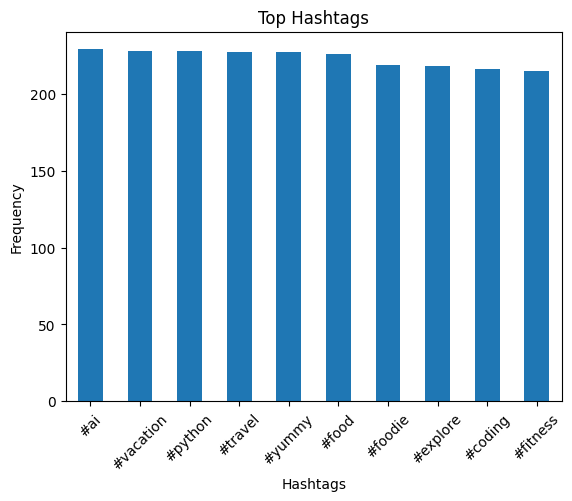

In [8]:
top_tags = hashtag_counts.head(10)

plt.figure()
top_tags.plot(kind='bar')

plt.xlabel("Hashtags")
plt.ylabel("Frequency")
plt.title("Top Hashtags")

plt.xticks(rotation=45)
plt.show()

**User group analysis**

In [17]:
# explode hashtags
# df_exploded = df.explode('hashtags')
# group_analysis = df_exploded.groupby(['user_type', 'hashtags']).size().unstack(fill_value=0)

# print(group_analysis)

hashes = df['hashtags'].explode()
analysis = hashes.groupby([df['user_type'], hashes]).size().unstack(fill_value=0)
print(analysis)

hashtags    #ai  #coding  #college  #content  #developer  #exam  #explore  \
user_type                                                                   
developer   229      216         0         0         206      0         0   
fitness       0        0         0         0           0      0         0   
foodie        0        0         0         0           0      0         0   
influencer    0        0         0       201           0      0         0   
student       0        0       198         0           0    206         0   
traveler      0        0         0         0           0      0       218   

hashtags    #fitness  #food  #foodie  ...  #reels  #restaurant  #study  \
user_type                             ...                                
developer          0      0        0  ...       0            0       0   
fitness          215      0        0  ...       0            0       0   
foodie             0    226      219  ...       0          215       0   
influencer   